# Modify the dust, chemistry, and aerosol emissions forcing files for CESM

This file is used to modify the values in a dataset by calculating:
- the global mean of a variable and assigning this mean value to all latitudes and longitudes ([global](#Global-Mean) section),
- the zonal mean of a variable and assigning this mean value to all latitudes ([zonal mean](#Simple-Zonal-Mean) section),
- the mirrored zonal mean of a variable ([mirror zonal mean](#Mirror-Zonal-Mean) section),
- a 0 value to all grid cell.

In [16]:
%matplotlib inline
import sys

# numpy/xarray/matplotlib
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [17]:
# Insert the path of the original file
old_path = 'Config/'
# Insert the path of the file you want to create
new_path = 'Config/'

In [18]:
# Name of the file (without the extension)
old_file = 'emissions-cmip6_DMS_bb_surface_1750-2015_0.9x1.25_c20170322'

In [19]:
ds_old = xr.open_dataset(old_path + old_file + '.nc')
print(ds_old.data_vars)
var_list = ['emiss_bb']

Data variables:
    date      (time) int32 ...
    emiss_bb  (time, lat, lon) float32 ...


### Function

In [20]:
def modify_cesm(ds_old, var_list, zeros = None, global_mean = None, simple_zonal_mean = None, mirror_zonal_mean = None):
    '''
    Create copy of an input file to calculate the idealized equivalent with several methods by erasing the geographical signature
    of a variable, using global mean and/or simple zonal mean and/or mirror_zonal_mean and/or zeros values.

    Args:
        ds_old (xarray): original dataset that will be copied to make changes
        var_list (list of str): list of variables that need to be changed
        
        zeros (bool): allows the function to create a copy of the dataset with 0 values at all longitudes and latitudes if True
        global_mean (bool): allows the function to create a copy with a global mean if True
        simple_zonal_mean (bool): allows the function to create a copy with values averaged by longitude if True
        mirror_zonal_mean (bool): allows the function to create a copy with values averaged by longitude AND mirrored by the equator if True

    Returns:
        ds_zeros (xarray): new dataset with 0 values at all longitudes and latitudes
        ds_mean_new (xarray): new dataset with global mean
        ds_zonal_new (xarray): new dataset with zonal mean
        ds_mirror_zonal_new (xarray): new dataset with mirrored zonal mean
    '''    
    # Creation of new Datasets
    ds_mirror_zonal_new = ds_old.copy()
    ds_zeros = ds_old.copy()
    ds_mean_new = ds_old.copy()
    ds_zonal_new = ds_old.copy()
    
    # do global mean area weighted average
    weights = np.cos(np.deg2rad(ds_old.lat))
    weights.name = "weights"

    if zeros :
        for var in var_list :
            # Set all the values to zeros
            ds_zeros[var] = ds_old[var]*0.0

    
    if global_mean :        
        weighted_mean = {}
        for var in var_list :
            da_weighted = ds_old[var].weighted(weights)
            weighted_mean[var] = da_weighted.mean(("lon", "lat"))
    
            # Set the calculated mean to the new dataset
            ds_mean_new[var] = ds_old[var]*0.0 + weighted_mean[var]#.values

    
    if simple_zonal_mean :        
        zonal_mean = {}
        for var in var_list :
            # Calcul of global mean over longitude and latitude
            zonal_mean[var] = ds_old[var].mean('lon')
                
            # Set the calculated zonal mean to the new dataset
            ds_zonal_new[var] = ds_old[var]*0.0 + zonal_mean[var]#.values

    
    if mirror_zonal_mean :

        zonal_mean = {}
        for var in var_list :
            # Calcul of global mean over longitude and latitude
            zonal_mean[var] = ds_old[var].mean('lon')
        
        mirror_zonal_mean = {}
        for var in var_list :
            mirror_zonal_mean[var] = (zonal_mean[var] + zonal_mean[var].isel(lat=slice(None, None, -1)).values) / 2

            # Set the calculated zonal mean to the new dataset
            ds_mirror_zonal_new[var] = ds_old[var]*0.0 + mirror_zonal_mean[var]#.values


    return ds_zeros, ds_mean_new, ds_zonal_new, ds_mirror_zonal_new

In [21]:
zero, gm, zm, mzm = modify_cesm(ds_old, var_list, zeros = 1, global_mean = 1, simple_zonal_mean = 1, mirror_zonal_mean = 1)

### Verification

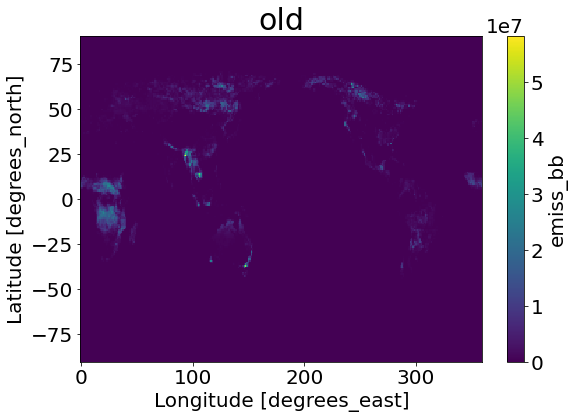

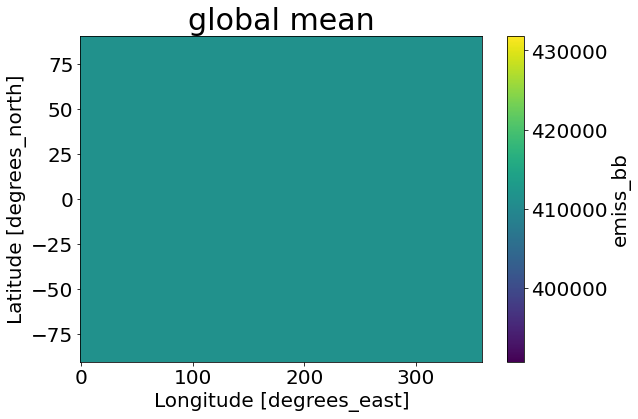

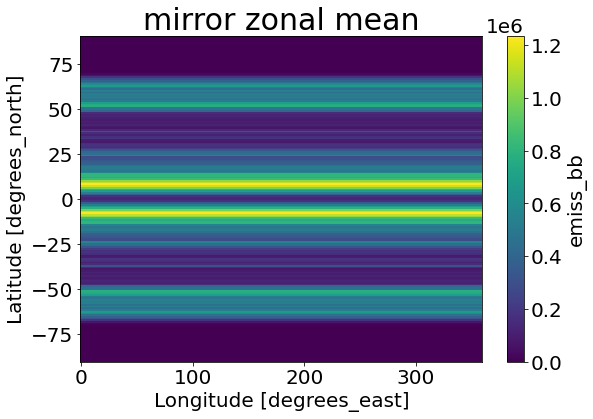

In [22]:
# Verification plots
for var in var_list :

    plt.figure(figsize=(9,6))
    ds_old[var].mean('time').plot()
    plt.title('old',fontsize=30)
    plt.rcParams.update({'font.size': 20, 'axes.titlesize': 20, 'axes.labelsize': 20, 'xtick.labelsize': 20, 'ytick.labelsize': 20})
    plt.show()
    plt.close()
    
    plt.figure(figsize=(9,6))
    gm[var].mean('time').plot()
    plt.title('global mean',fontsize=30)
    plt.rcParams.update({'font.size': 20, 'axes.titlesize': 20, 'axes.labelsize': 20, 'xtick.labelsize': 20, 'ytick.labelsize': 20})
    plt.show()
    plt.close()
    
    plt.figure(figsize=(9,6))
    mzm[var].mean('time').plot()
    plt.title('mirror zonal mean',fontsize=30)
    plt.rcParams.update({'font.size': 20, 'axes.titlesize': 20, 'axes.labelsize': 20, 'xtick.labelsize': 20, 'ytick.labelsize': 20})
    plt.show()
    plt.close()
    
# If there is another dimension (for example a mean for each lev value), use:
# ds_new[var].isel(lev=0).plot() --> plot the average for the first altitude level

### Export

In [23]:
# Create a NetCDF file with the new datasets
zero.to_netcdf(new_path + old_file + '_zeros.nc')
gm.to_netcdf(new_path + old_file + '_globalmean.nc')
zm.to_netcdf(new_path + old_file + '_zonalmean.nc')
mzm.to_netcdf(new_path + old_file + '_mirrormean.nc')